# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how Bitcoin market sentiment (Fear vs Greed) impacts trader behavior and performance.

---

## Datasets Used
1. Fear & Greed Index Dataset  
2. Hyperliquid Historical Trader Dataset  

---

## Goals
- Understand profitability patterns
- Analyze trading behavior
- Identify trader segments
- Generate actionable strategies

# Author : Mihir Kulkarni

## Step 1: Load Datasets

In [5]:
sentiment = pd.read_csv("fear_greed_index (1).csv")
trade = pd.read_csv("historical_data (1).csv")

print("Sentiment Shape:", sentiment.shape)
print("Trade Shape:", trade.shape)

Sentiment Shape: (2644, 4)
Trade Shape: (211224, 16)


## Step 2: Data Inspection

In [8]:
print(sentiment.head())
print(trade.head())

print("\nMissing Values:")
print(sentiment.isnull().sum())
print(trade.isnull().sum())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

## Step 3: Timestamp Conversion

In [11]:
trade['time'] = pd.to_datetime(
    trade['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

trade['date'] = trade['time'].dt.date

## Step 4: Prepare Sentiment Data

In [16]:
sentiment['Date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['Date'].dt.date

sentiment.rename(columns={'Classification': 'classification'}, inplace=True)

## Step 5: Merge Datasets

In [19]:
df = pd.merge(
    trade,
    sentiment[['date', 'classification']],
    on='date',
    how='inner'
)

print("Merged Shape:", df.shape)

Merged Shape: (211218, 19)


## Step 6: Feature Engineering

In [22]:
# Direction
df['Direction'] = df['Side'].apply(
    lambda x: 'Long' if x.lower() == 'buy' else 'Short'
)

# Position Size
df['position_size'] = df['Size USD'] / df['Execution Price']

# Win/Loss
df['win'] = df['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

## Step 7: Create Output Folders

In [25]:
os.makedirs("charts", exist_ok=True)
os.makedirs("results", exist_ok=True)

## Step 8: Average PnL by Sentiment

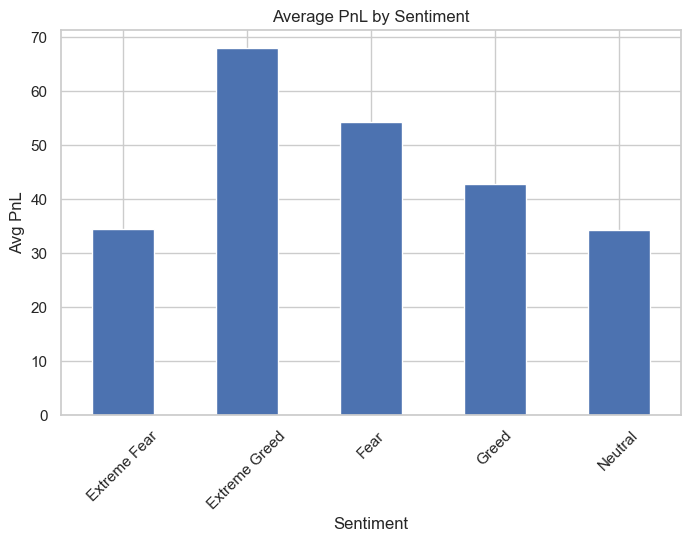

In [28]:
pnl_sentiment = df.groupby('classification')['Closed PnL'].mean()

plt.figure(figsize=(8,5))
pnl_sentiment.plot(kind='bar')

plt.title("Average PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg PnL")

plt.xticks(rotation=45)

plt.savefig("charts/pnl_vs_sentiment.png", bbox_inches='tight')
plt.show()

## Step 9: Profit Distribution

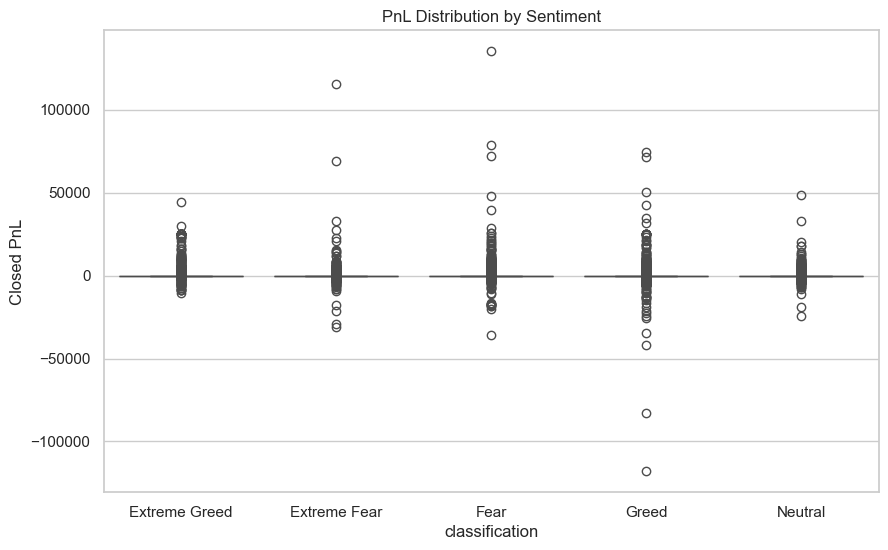

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(x='classification', y='Closed PnL', data=df)

plt.title("PnL Distribution by Sentiment")

plt.savefig("charts/pnl_distribution.png", bbox_inches='tight')
plt.show()

## Step 10: Trade Frequency

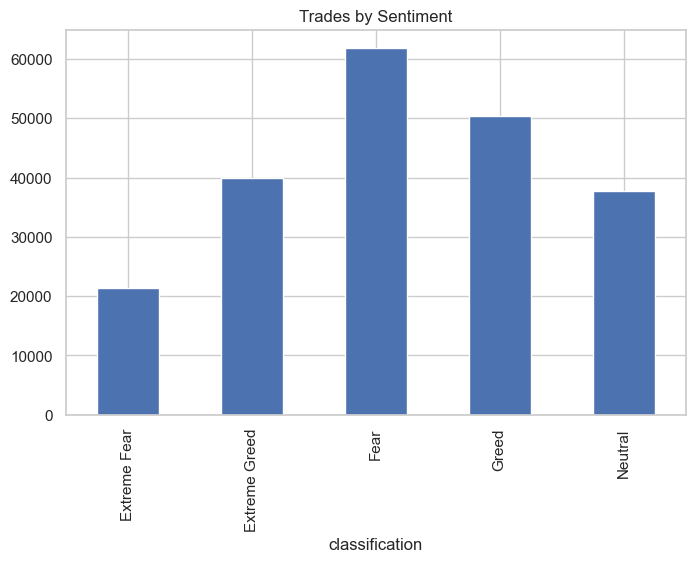

In [34]:
trade_freq = df.groupby('classification').size()

plt.figure(figsize=(8,5))
trade_freq.plot(kind='bar')

plt.title("Trades by Sentiment")

plt.savefig("charts/trade_frequency.png", bbox_inches='tight')
plt.show()

## Step 11: Long vs Short Analysis

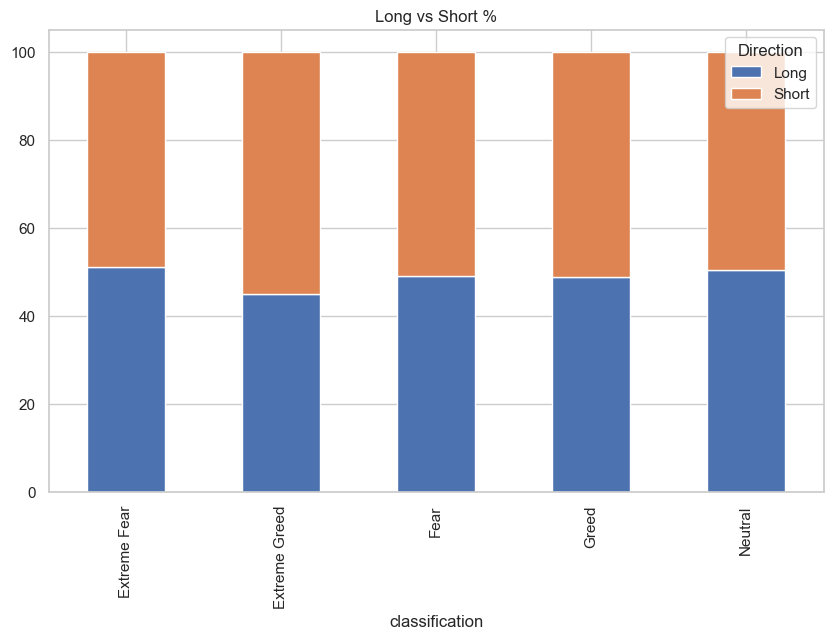

In [37]:
direction_sentiment = pd.crosstab(
    df['Direction'],
    df['classification'],
    normalize='columns'
) * 100

direction_sentiment.T.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Long vs Short %")

plt.savefig("charts/long_short_ratio.png", bbox_inches='tight')
plt.show()

## Step 12: Position Size Analysis

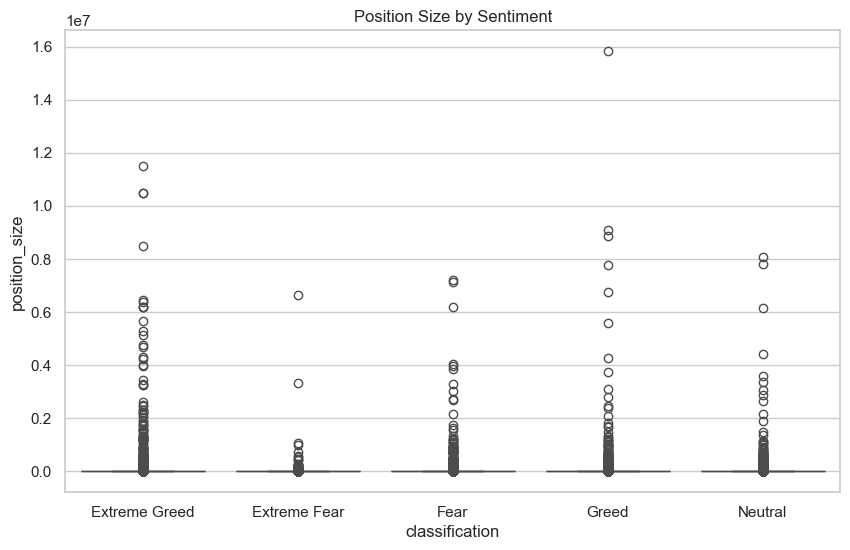

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(x='classification', y='position_size', data=df)

plt.title("Position Size by Sentiment")

plt.savefig("charts/position_size.png", bbox_inches='tight')
plt.show()

## Step 13: Trader Activity Segmentation

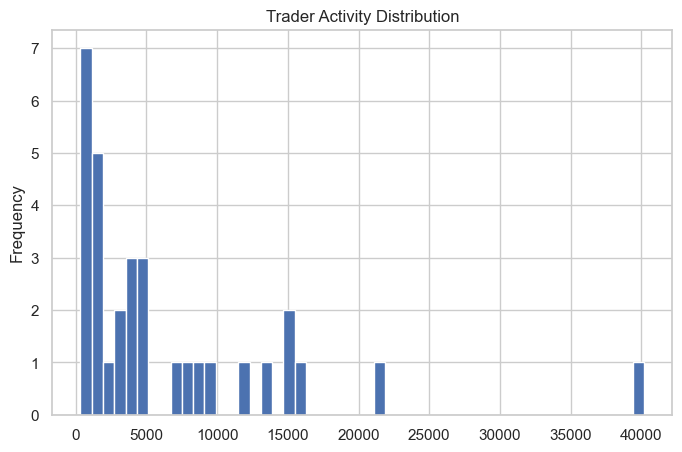

In [43]:
trader_activity = df.groupby('Account').size()

plt.figure(figsize=(8,5))
trader_activity.plot(kind='hist', bins=50)

plt.title("Trader Activity Distribution")

plt.savefig("charts/trader_activity.png", bbox_inches='tight')
plt.show()

## Step 14: Save Results

In [46]:
df.to_csv("results/merged_dataset.csv", index=False)

pnl_sentiment.to_csv("results/pnl_by_sentiment.csv")
trade_freq.to_csv("results/trade_frequency.csv")
direction_sentiment.to_csv("results/direction_sentiment.csv")

## Key Insights

1. Traders show higher average profitability during Greed periods.

2. Fear markets show higher volatility with more negative outliers.

3. Trade frequency increases during Greed sentiment.

4. Long positions dominate in Greed markets.

5. Traders take larger position sizes during Greed periods, indicating higher risk-taking.

---

## Strategy Recommendations

1. Reduce leverage and position size during Fear markets to minimize risk.

2. Focus on momentum-based long strategies during Greed markets.

---

## Conclusion

Market sentiment has a strong influence on trader behavior and performance.  
Understanding these patterns can help optimize trading strategies and risk management.